In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Jacobi Method implementation with error tracking
def jacobi(A, b, x0, tol, max_iterations=1000):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        # Calculate absolute error between iterations
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        
        # Check for convergence
        if error < tol:
            return x_new, k + 1, errors
        x = x_new
        
    return x, max_iterations, errors

# Gauss-Seidel Method implementation with error tracking
def gauss_seidel(A, b, x0, tol, max_iterations=1000):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
        # Calculate absolute error between iterations
        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)
        
        # Check for convergence
        if error < tol:
            return x_new, k + 1, errors
        x = x_new
        
    return x, max_iterations, errors

In [2]:
# System of equations
A = np.array([
    [3.0, -0.1, -0.2],
    [0.1,  7.0, -0.3],
    [0.3, -0.2, 10.0]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)
x0 = np.array([0.0, 0.0, 0.0], dtype=float)

tolerances = [1e-3, 1e-6, 1e-9]

# Dictionaries to store the error histories for plotting later
jacobi_errors = {}
gs_errors = {}

print("--- Comparing Iterations Required to Converge ---\n")

for tol in tolerances:
    print(f"Tolerance: {tol}")
    
    # Run Jacobi
    sol_j, iters_j, errs_j = jacobi(A, b, x0, tol)
    jacobi_errors[tol] = errs_j
    print(f"  Jacobi       -> Iterations: {iters_j:2d} | Solution: {sol_j}")
    
    # Run Gauss-Seidel
    sol_gs, iters_gs, errs_gs = gauss_seidel(A, b, x0, tol)
    gs_errors[tol] = errs_gs
    print(f"  Gauss-Seidel -> Iterations: {iters_gs:2d} | Solution: {sol_gs}")
    print("-" * 75)

--- Comparing Iterations Required to Converge ---

Tolerance: 0.001
  Jacobi       -> Iterations:  4 | Solution: [ 3.0000225  -2.50000266  6.99998104]
  Gauss-Seidel -> Iterations:  4 | Solution: [ 3.00000035 -2.50000004  6.99999999]
---------------------------------------------------------------------------
Tolerance: 1e-06
  Jacobi       -> Iterations:  7 | Solution: [ 3.  -2.5  7. ]
  Gauss-Seidel -> Iterations:  5 | Solution: [ 3.  -2.5  7. ]
---------------------------------------------------------------------------
Tolerance: 1e-09
  Jacobi       -> Iterations:  9 | Solution: [ 3.  -2.5  7. ]
  Gauss-Seidel -> Iterations:  7 | Solution: [ 3.  -2.5  7. ]
---------------------------------------------------------------------------


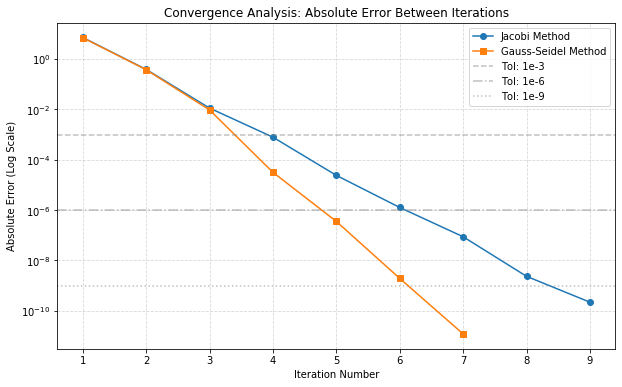

In [3]:
# We will plot the error history for the strictest tolerance (1e-9)
# since it shows the full progression of the error reduction.
tol_to_plot = 1e-9

plt.figure(figsize=(10, 6))

# Plot Jacobi errors
plt.plot(range(1, len(jacobi_errors[tol_to_plot]) + 1), 
         jacobi_errors[tol_to_plot], 
         marker='o', label='Jacobi Method')

# Plot Gauss-Seidel errors
plt.plot(range(1, len(gs_errors[tol_to_plot]) + 1), 
         gs_errors[tol_to_plot], 
         marker='s', label='Gauss-Seidel Method')

# Formatting the plot
plt.yscale('log') # Use logarithmic scale since error drops exponentially
plt.xlabel('Iteration Number')
plt.ylabel('Absolute Error (Log Scale)')
plt.title('Convergence Analysis: Absolute Error Between Iterations')
plt.axhline(y=1e-3, color='gray', linestyle='--', alpha=0.5, label='Tol: 1e-3')
plt.axhline(y=1e-6, color='gray', linestyle='-.', alpha=0.5, label='Tol: 1e-6')
plt.axhline(y=1e-9, color='gray', linestyle=':', alpha=0.5, label='Tol: 1e-9')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

### Discussion: Tolerance and Convergence

* **Tolerance vs. Iterations:** Stricter tolerances (e.g., $10^{-9}$ vs $10^{-3}$) require more iterations to achieve the necessary precision.
* **Jacobi vs. Gauss-Seidel:** Gauss-Seidel converges in fewer iterations than Jacobi because it immediately uses updated variable values as they are computed, rather than waiting for the next cycle.
* **Matrix Condition:** Both methods converge quickly in this problem because the coefficient matrix is strictly diagonally dominant.